# Box Model - flopy

## Model Description 
This intially constructs the 2D (heterogeneous) steady state box model that you built for your BoxModel_Manual assignment

#### Dimensions: 
- 25 by 25 by 1
- dx = dy = 100 m
- dz = 10 m  

#### Subsurface Properties: 
- Heterogeneous 
- K = 1.0 m/day in x, y and z with a 5x5 inclusion with K = 0.1 m/day centered in the domain.  Inclusion is 5x5 cells.
- Porosity = 0.35
- Specific yield = 0.3
- Storage coefficient=0.001  

#### Boundary Conditions: 
 - Right boundary is constant head of 10 m relative to the datum, which is located at the bottom of the domain.  
 - Left boundary is a constant head of 20 m relative to the datum, which is located at the bottom of the domain.


In [1]:
#the basics
import flopy
import numpy as np
import matplotlib as mp
import os

#additional analysis tools
import flopy.utils.binaryfile as bf
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
import csv

#jupyter specific--included to show plots in notebook
%matplotlib inline 

#Supress depricaiton warmnings
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

# If you want to calculate the harmonic mean in python you need to conda install scipy 
# and uncomment this line
from scipy.stats import hmean

In [2]:
modelname = "BoxModel_flopy"
moddir = '../../../modflow/mf2005'
m = flopy.modflow.Modflow(modelname, exe_name = moddir)

/opt/conda/envs/hwrs564b/lib/python3.11/site-packages/flopy/mbase.py:105: UserWarning: The program ../../../modflow/mf2005 does not exist or is not executable.
  warn(


In [3]:
#optional delete old run files
run = 'n'
if run == 'y':
    # file_extensions = ['.dis','.bas','.lpf','.oc','.pcg','.wel']
    file_extensions = ['.dis','.bas','.bcf','.oc','.pcg']
    for ext in file_extensions:
        os.remove(modelname + ext)

## 3. Setup the discretization (DIS package)

For more details on DIS package inputs refer to : https://flopy.readthedocs.io/en/3.3.2/source/flopy.modflow.mfdis.html 

#### 3.1 Spatial discretization

In [ ]:
nrow = 40 #number of rows
ncol = 40 #number of columns
nlay = 1  #number of layers

dx= 100 #width of grid cells in x direction 
dy= 100 #width of grid cells in y direction 

Lx = ncol*dx  #width of domain in x
Ly = nrow*dy #width of domain in y
ztop = 250.    #top elevation 
zbot = 0.     #bottom elevation

dz = (ztop - zbot) / nlay #cell height in z direction

In [12]:
nper = 1 #number of stress periods 
steady = [True] #list noting the stress period type

In [13]:
#create flopy discretization object, length and time are meters (2) and days (4)
dis = flopy.modflow.ModflowDis(model=m, nlay=nlay, nrow=nrow, ncol=ncol, 
                               delr=dx, delc=dy, top=ztop, botm=zbot, 
                               itmuni = 4, lenuni = 2, 
                               nper=nper, steady=steady)

/opt/conda/envs/hwrs564b/lib/python3.11/site-packages/flopy/mbase.py:623: UserWarning: Unit 11 of package DIS already in use.
  warn(
/opt/conda/envs/hwrs564b/lib/python3.11/site-packages/flopy/mbase.py:632: UserWarning: Two packages of the same type, Replacing existing 'DIS' package.
  warn(


#### 3.4 Plot the grid

For help on this function see: https://flopy.readthedocs.io/en/3.3.2/source/flopy.plot.plotutil.html

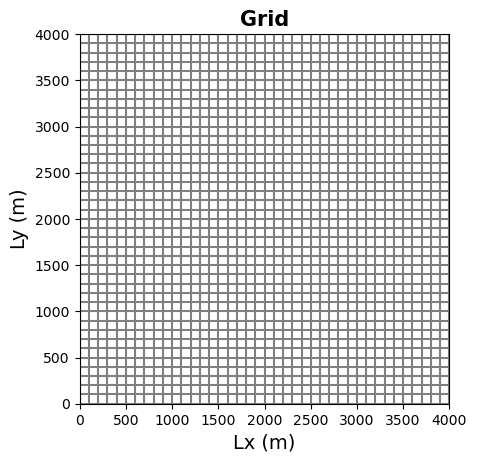

In [14]:
#use flopy to plot the grid of model 'm'
modelmap = flopy.plot.PlotMapView(model=m, layer=0)
grid = modelmap.plot_grid() 
plt.xlabel('Lx (m)',fontsize = 14)
plt.ylabel('Ly (m)',fontsize = 14)
plt.title('Grid', fontsize = 15, fontweight = 'bold')
plt.show()

## 4. Setup constant head boundaries, active cells and initial heads (BAS Package)

For more details on the BAS package see: https://flopy.readthedocs.io/en/3.3.2/source/flopy.modflow.mfbas.html

#### 4.1 Define cell activity: IBOUND 


In [19]:
#create ibound as array of ints = 1
ibound = np.ones((nlay, nrow, ncol), dtype=np.int32) #integer array of dim (z,y,x), makes all cells active     

#set constant head boundary on the left
ibound[:,:,0] = -1          #layer, row, column (z,y,x) replace leftmost column (all zs, all ys, first x) with -1 to indicate constant head 
ibound[:,:,-1] = -1          #replace leftmost column (all zs, all ys, first x) with -1 to indicate constant head (-1 = very last column)

#print("ibound values: \n", ibound)

#### 4.2 Define starting heads 

In [20]:
#setup initial heads as 1 everywhere and 7 on the left boundary 
H_init = np.ones((nlay, nrow, ncol), dtype=np.float32)  #float array (i.e. decimal), sets all heads to 1.0
H_init[:, :, 0] = 245    #replace first (left) col with desired head value
H_init[:, :, -1] = 200    #replace first (left) col with desired head value

#print("starting head values: \n", H_init)

#### 4.3 Create BAS object

In [22]:
#create flopy bas object
bas = flopy.modflow.ModflowBas(m, ibound=ibound, strt=H_init)

/opt/conda/envs/hwrs564b/lib/python3.11/site-packages/flopy/mbase.py:623: UserWarning: Unit 13 of package BAS6 already in use.
  warn(
/opt/conda/envs/hwrs564b/lib/python3.11/site-packages/flopy/mbase.py:632: UserWarning: Two packages of the same type, Replacing existing 'BAS6' package.
  warn(


#### 4.4 Plot the grid and ibound

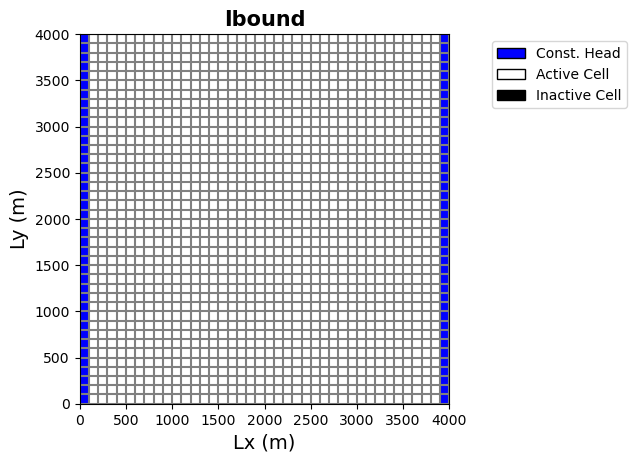

In [23]:
#plot grid and ibound
modelmap = flopy.plot.PlotMapView(model=m, layer=0)
grid = modelmap.plot_grid()
ib = modelmap.plot_ibound()
#add labels and legend
plt.xlabel('Lx (m)',fontsize = 14)
plt.ylabel('Ly (m)',fontsize = 14)
plt.title('Ibound', fontsize = 15, fontweight = 'bold')
plt.legend(handles=[mp.patches.Patch(color='blue',label='Const. Head',ec='black'),
                   mp.patches.Patch(color='white',label='Active Cell',ec='black'),
                   mp.patches.Patch(color='black',label='Inactive Cell',ec='black')],
                   bbox_to_anchor=(1.5,1.0))
plt.show(modelmap)

## 5. Setup Layer Properties  (LPF Package)

For more details on LPF package see: https://flopy.readthedocs.io/en/3.3.2/source/flopy.modflow.mflpf.html

#### 5.1 Set layer properties

In [25]:
K_horiz = 1.    #horizontal hydraulic conductivity 
K_vert = 1    #assign vertical hydraulic conductivity (along z axis)
n = 0.35        #assign porosity
Ss = 0.001      #assign storage coefficient
Sy = 0.3        #assign specific yield
uncnf = 0       #0=confined, >0 = unconfined

#### 5.2 Make LPF object

In [26]:
#assigns horizontal and vertical Ks and saves cell-by-cell budget data
# lpf = flopy.modflow.ModflowLpf(m, laytyp=uncnf, hk=K_horiz, 
#                                vka=K_vert, ss=Ss,
#                                sy=Sy,storagecoefficient=True, ipakcb=53) 


## 5b. Setup Cell-byCell Properties  (BCF Package)

For more details on LPF package see: https://flopy.readthedocs.io/en/3.3.2/source/flopy.modflow.mfbcf.html

#### 5b.1 Set cell properties and show K in top layer

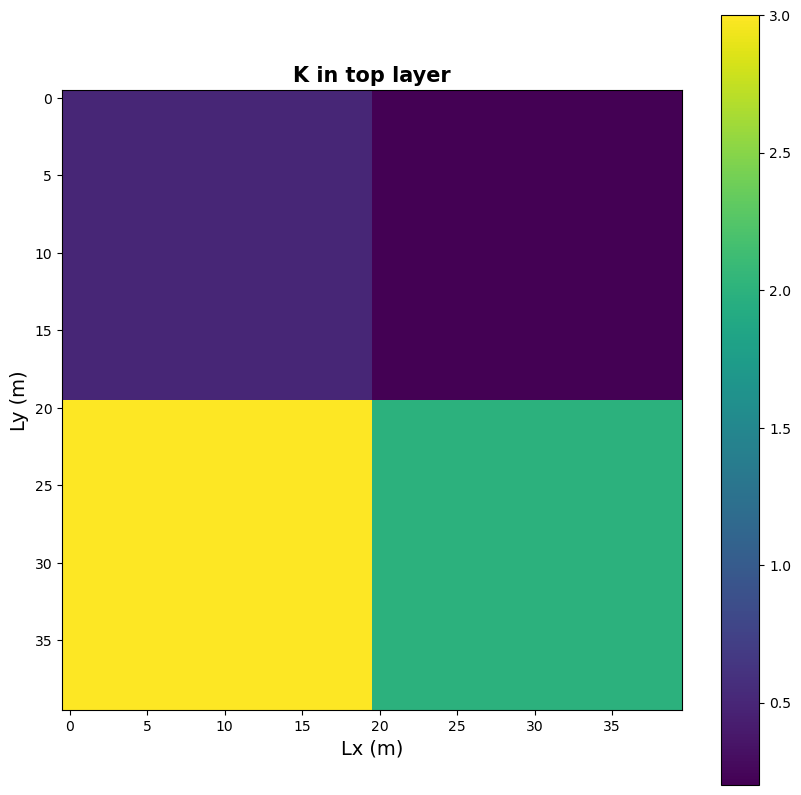

In [49]:
K_vals = np.zeros((nlay,nrow,ncol))

K_vals[:,:,:] = 1 # (layer, row, column)

#K_vals[:,:int(Ly/2+1),:int(Lx/2+1)] = 1             # homoogeneous background hydraulic conductivity 


K_incl_Q1 = 0.2 # K inclusion value
K_vals[:,20:40,20:40] = K_incl_Q1

K_incl_Q2 = 0.5 # K inclusion value
K_vals[:,20:40,0:20] = K_incl_Q2

K_incl_Q3 = 3.0 # K inclusion value
K_vals[:,0:20,0:20] = K_incl_Q3

K_incl_Q4 = 2.0 # K inclusion value
K_vals[:,0:20,20:40] = K_incl_Q4

#how to make an irregular , non-iso boundary?




n = 0.35        #assign porosity
Ss = 0.001      #assign storage coefficient
Sy = 0.3        #assign specific yield
uncnf = 0       #0=confined, >0 = unconfined

#plot K values in top layer
fig1 = plt.figure(figsize=(10,10)) #create 10 x 10 figure
plt.xlabel('Lx (m)',fontsize = 14)
plt.ylabel('Ly (m)',fontsize = 14)
plt.title('K in top layer', fontsize = 15, fontweight = 'bold')
plt.imshow(np.flipud(K_vals[0,:,:]), interpolation='none')
plt.colorbar()
plt.show()

#### 5b.2 Make BCF object